<a href="https://colab.research.google.com/github/ealger22/main/blob/CSC-302-Data-Visualization/ICA7_box_office.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


✅ Successfully loaded dataset!

📊 First few rows of the dataset:


,rank,title,title_short,amount,amount_text
0,1,Star Wars: The Last Jedi,Star Wars,71565498,$71
1,2,Jumanji: Welcome to the Jungle,Jumanji,36169328,$36
2,3,Pitch Perfect 3,Pitch Perfect 3,19928525,$19
3,4,The Greatest Showman,Greatest Showman,8805843,$8
4,5,Ferdinand,Ferdinand,7316746,$7



🎬 Box Office Revenue for Star Wars: **$71,565,498**


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


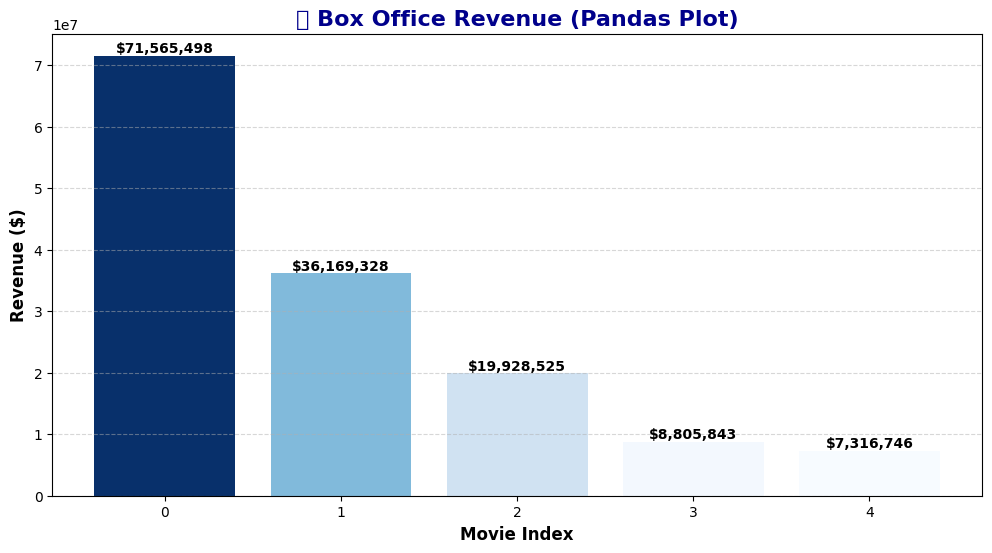

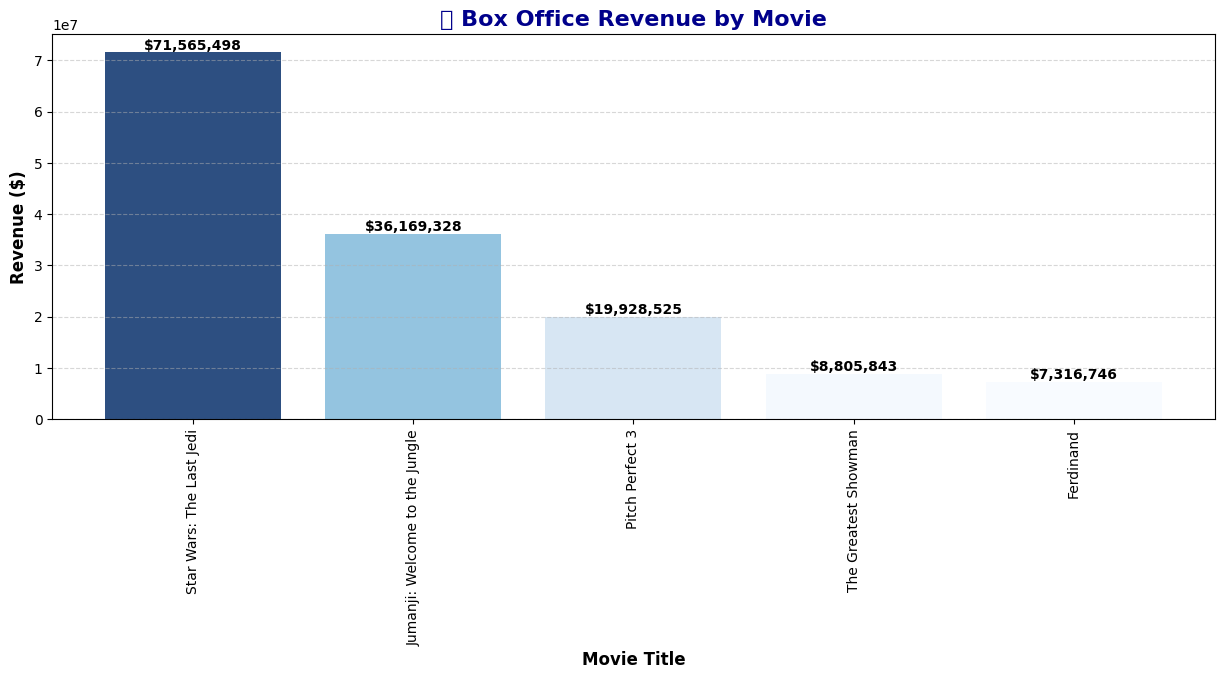

In [5]:
# 📌 Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 📌 Define file path (adjust if needed)
file_path = "/content/drive/My Drive/ColabFiles/boxoffice.csv"

# 📌 Load dataset with error handling
try:
    boxoffice = pd.read_csv(file_path)
    print("✅ Successfully loaded dataset!")
except FileNotFoundError:
    print(f"❌ Error: File not found at {file_path}. Please check the file path.")
    boxoffice = None

# 📌 Proceed only if data is loaded successfully
if boxoffice is not None:
    print("\n📊 First few rows of the dataset:")
    display(boxoffice.head())  # Works in Google Colab / Jupyter

    # 📌 Retrieve the revenue for "Star Wars" using loc with formatted output
    try:
        star_wars_amount = boxoffice.loc[boxoffice['title_short'] == 'Star Wars', 'amount'].values[0]
        print(f"\n🎬 Box Office Revenue for Star Wars: **${star_wars_amount:,.0f}**")
    except IndexError:
        print("\n⚠️ Warning: 'Star Wars' not found in the dataset.")

    # 📌 Normalize revenue for color mapping
    norm = plt.Normalize(boxoffice['amount'].min(), boxoffice['amount'].max())
    colors = plt.cm.Blues(norm(boxoffice['amount']))  # Use gradient blue colors

    # 📌 Generate the first bar chart using Pandas
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(boxoffice.index, boxoffice['amount'], color=colors)

    # 🔹 Add data labels on bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, f"${yval:,.0f}",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

    # 🔹 Format the chart
    ax.set_title("🎬 Box Office Revenue (Pandas Plot)", fontsize=16, fontweight='bold', color='darkblue')
    ax.set_xlabel("Movie Index", fontsize=12, fontweight='bold')
    ax.set_ylabel("Revenue ($)", fontsize=12, fontweight='bold')
    ax.grid(axis="y", linestyle="--", alpha=0.5)  # Add grid for readability

    # 🔹 Display the plot
    plt.show()

    # 📌 Generate the second bar chart using Matplotlib
    fig, ax = plt.subplots(figsize=(15, 5))
    bars = ax.bar(boxoffice['title'], boxoffice['amount'], color=colors, alpha=0.85)

    # 🔹 Add data labels above bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, f"${yval:,.0f}",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

    # 🔹 Rotate x-axis labels for readability
    plt.xticks(rotation=90, fontsize=10)

    # 🔹 Format the chart
    ax.set_title("🎬 Box Office Revenue by Movie", fontsize=16, fontweight='bold', color='darkblue')
    ax.set_xlabel("Movie Title", fontsize=12, fontweight='bold')
    ax.set_ylabel("Revenue ($)", fontsize=12, fontweight='bold')
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # 🔹 Display the plot
    plt.show()


[1] "📊 First 5 rows of the dataset (5x5 format):"
  rank                          title      title_short      amount amount_text
1    1       Star Wars: The Last Jedi        Star Wars $71,565,498        $71 
2    2 Jumanji: Welcome to the Jungle          Jumanji $36,169,328        $36 
3    3                Pitch Perfect 3  Pitch Perfect 3 $19,928,525        $19 
4    4           The Greatest Showman Greatest Showman  $8,805,843         $8 
5    5                      Ferdinand        Ferdinand  $7,316,746         $7 
[1] "🎬 Box Office Revenue for Star Wars: $71,565,498"


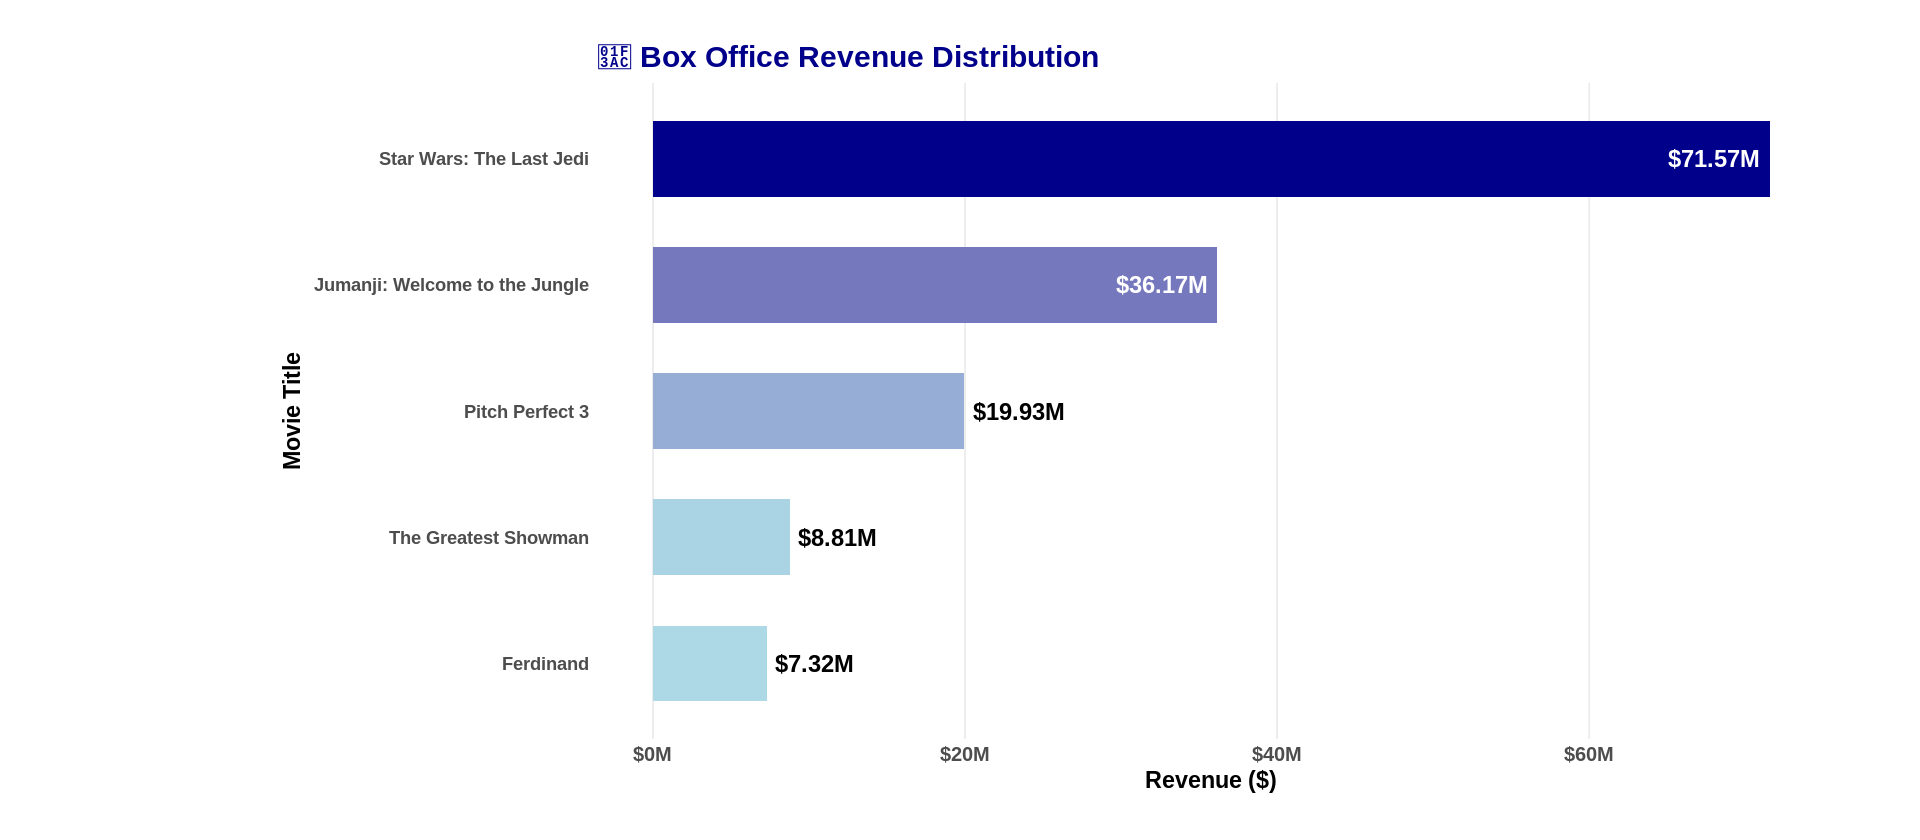

In [10]:
# 📌 Load required libraries
library(ggplot2)
library(dplyr)
library(scales)  # For formatting numbers

# 📌 Set a wider figure size for better readability
options(repr.plot.width=16, repr.plot.height=7)  # Increase height slightly

# 📌 Define file path (adjust if needed)
file_path <- "/content/drive/My Drive/ColabFiles/boxoffice.csv"

# 📌 Load dataset in R
boxoffice <- read.csv(file_path)

# 📌 Convert "amount" to numeric before formatting
boxoffice$amount <- as.numeric(boxoffice$amount)

# 📌 Create a 5x5 table with properly formatted numbers
boxoffice_formatted <- boxoffice %>%
  mutate(amount = dollar(amount)) %>%  # Format amount with dollar sign & commas
  select(rank, title, title_short, amount, amount_text)  # Keep the original 5 columns

# 📌 Display the 5x5 formatted table
print("📊 First 5 rows of the dataset (5x5 format):")
print(boxoffice_formatted[1:5, ])  # Display first 5 rows as a single table

# 📌 Output the amount for "Star Wars" with proper formatting
star_wars_amount <- boxoffice %>% filter(title_short == "Star Wars") %>% select(amount)

if (nrow(star_wars_amount) > 0) {
  formatted_amount <- dollar(star_wars_amount$amount)
  print(paste("🎬 Box Office Revenue for Star Wars:", formatted_amount))
} else {
  print("⚠️ Warning: 'Star Wars' not found in dataset.")
}

# 📌 Sort movies by revenue (descending)
boxoffice <- boxoffice %>% arrange(desc(amount))

# **Dynamic text positioning**
# - Labels go **inside** bars if revenue is high
# - Labels go **outside** bars if revenue is low
threshold <- max(boxoffice$amount) * 0.3  # Define threshold for placing labels inside/outside bars

# 📌 Create a professional bar chart with text inside large bars & outside for small bars
ggplot(boxoffice, aes(x=reorder(title, amount), y=amount, fill=amount)) +
  geom_bar(stat="identity", show.legend=FALSE, width=0.6) +  # Adjusted width for spacing
  scale_fill_gradient(low="lightblue", high="darkblue") +  # Softer gradient for clarity
  geom_text(aes(
    label = dollar(amount, scale=1e-6, suffix="M"),  # Display labels in millions
    hjust = ifelse(amount > threshold, 1.1, -0.1),   # Adjust text position dynamically
    color = ifelse(amount > threshold, "white", "black")  # White inside, black outside
  ), size=5, fontface="bold") +  # Adjust font size
  scale_color_identity() +  # Ensures correct colors in ggplot
  theme_minimal() +  # Clean, modern theme
  labs(title="🎬 Box Office Revenue Distribution",
       x="Movie Title",
       y="Revenue ($)") +  # Chart labels
  coord_flip() +  # Flip for better readability
  theme(
    plot.title = element_text(size=18, face="bold", color="darkblue"),  # Styled title
    axis.text.x = element_text(size=12, face="bold"),  # Bold x-axis labels
    axis.text.y = element_text(size=11, face="bold"),  # Bold y-axis labels
    axis.title = element_text(size=14, face="bold"),
    panel.grid.major.y = element_blank(),  # Remove y-axis grid for clarity
    panel.grid.minor = element_blank(),
    plot.margin = margin(1, 2, 1, 6, "cm")  # Increase left margin for text fitting
  ) +
  scale_y_continuous(labels = dollar_format(scale=1e-6, suffix="M"))  # Format y-axis in millions
